# Exploratory Data Analysis (EDA) dari Review Aplikasi CapCut #
Exploratory Data Analysis pada data review aplikasi CapCut ini meliputi:
1. Eksplorasi Distribusi Skor
2. Analisis Jumlah Rating
3. Analisis Panjang Review oleh User
4. Analisis Panjang Review Terhadap Rating User
5. Analisis 10 Kata Dengan Frekuensi Tertinggi

In [2]:
!pip install matplotlib

^C



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

In [5]:
df = pd.read_csv('../csv/capcut_reviews_raw.csv')
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,lang
0,95c4c332-22f7-4a3e-9049-83ff9ee11a8b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jangan jadi pro semua dong balikin versi gak p...,1,0,17.2.0,2026-03-25 12:35:32,NaN,NaN,17.2.0,id
1,5ac7bfec-8739-497b-bf98-0d56b6c4dd73,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sekolah SD 4 darul aman,5,0,NaN,2026-03-25 12:35:25,NaN,NaN,NaN,id
2,6f34c887-fe3e-4f20-85b8-d7a77d898eb0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya si tdk rekomendasi aplikasi capcut ini ha...,1,0,17.2.0,2026-03-25 12:29:58,NaN,NaN,17.2.0,id
3,29d9d210-06ae-4c46-a3f8-828cf011bb31,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya coba dulu,4,0,NaN,2026-03-25 12:28:15,NaN,NaN,NaN,id
4,e682a46c-5d79-4b82-9ad2-40307d56d2d6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ah- ahh ah mphh a-ah,1,0,17.2.0,2026-03-25 12:26:53,NaN,NaN,17.2.0,id


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              10000 non-null  object
 1   userName              10000 non-null  object
 2   userImage             10000 non-null  object
 3   content               9999 non-null   object
 4   score                 10000 non-null  int64 
 5   thumbsUpCount         10000 non-null  int64 
 6   reviewCreatedVersion  4317 non-null   object
 7   at                    10000 non-null  object
 8   replyContent          23 non-null     object
 9   repliedAt             23 non-null     object
 10  appVersion            4317 non-null   object
 11  lang                  10000 non-null  object
dtypes: int64(2), object(10)
memory usage: 937.6+ KB


### Transform Datetime ###
Merubah 'dtype' column 'at' menjadi 'datetime'

In [7]:
df['at'] = pd.to_datetime(df['at'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              10000 non-null  object        
 1   userName              10000 non-null  object        
 2   userImage             10000 non-null  object        
 3   content               9999 non-null   object        
 4   score                 10000 non-null  int64         
 5   thumbsUpCount         10000 non-null  int64         
 6   reviewCreatedVersion  4317 non-null   object        
 7   at                    10000 non-null  datetime64[ns]
 8   replyContent          23 non-null     object        
 9   repliedAt             23 non-null     object        
 10  appVersion            4317 non-null   object        
 11  lang                  10000 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 937.6+ KB


### Eksplorasi Distribusi Rating User ###

Jumlah review bahasa Indonesia: 10000


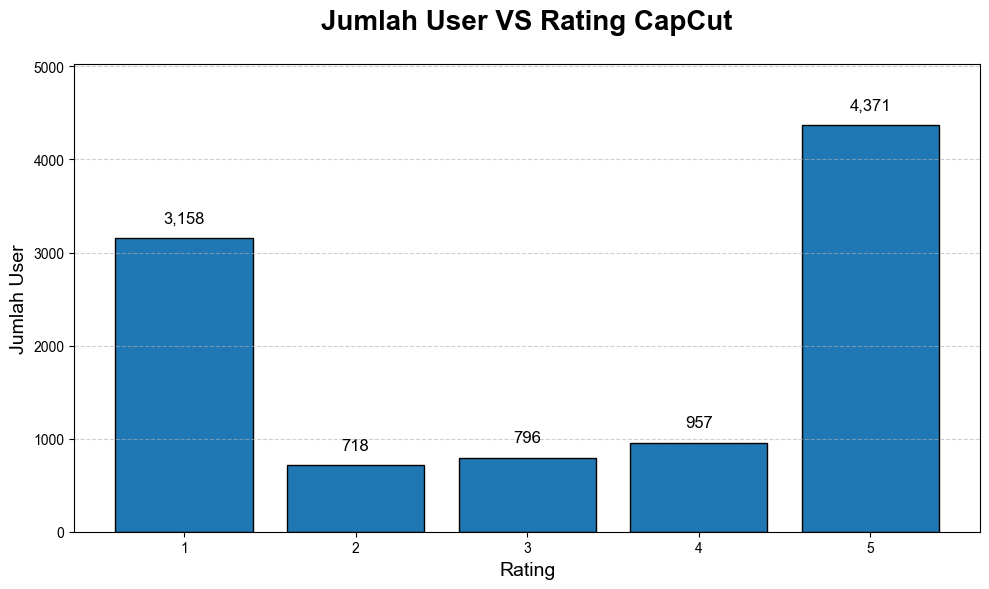

In [8]:
print(f"Jumlah review bahasa Indonesia: {len(df)}")
df["score"].value_counts().sort_index()

df_count = df['score'].value_counts().sort_index()

plt.figure(figsize=(10, 6))

# Plot bar
bars = plt.bar(df_count.index, df_count.values, edgecolor='black', linewidth=1)

# Judul & label
plt.title('Jumlah User VS Rating CapCut', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Rating', fontsize=14)
plt.ylabel('Jumlah User', fontsize=14)

# Tambah ruang di atas
max_val = max(df_count.values)
plt.ylim(top=max_val * 1.15)

# Grid halus
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Tambah label nilai pada bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max_val * 0.03,
        f"{height:,}",
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.tight_layout()
plt.show()
     


### Analisis Jumlah Rating per April 2026 ###
Visualisasi trendine digunakan untuk memahami perkembangan/penurunan jumlah rating aplikasi CapCut per hari pada April 2026.

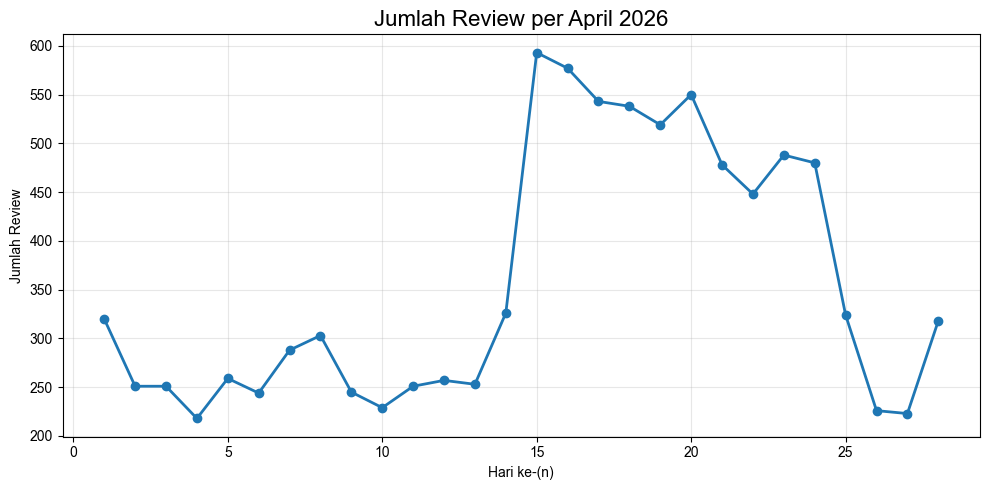

In [9]:
df_day = df.groupby(df['at'].dt.day).size()

plt.figure(figsize=(10,5))
plt.plot(df_day.index, df_day.values, marker='o', linewidth=2)

plt.title("Jumlah Review per April 2026", fontsize=16)
plt.xlabel("Hari ke-(n)")
plt.ylabel("Jumlah Review")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analisis Panjang Review Oleh User ###
Analisis ini dilakukan untuk mengetahui padatan informasi yang tercantum dalam sebuah data yang tersedia yang selanjutnya dapat diproses lebih lanjut pada analisis sentimen.  

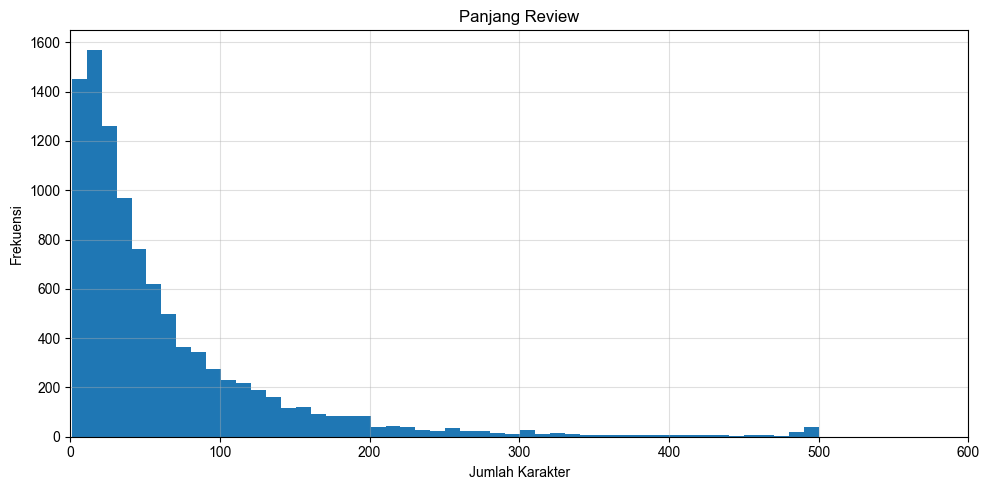

In [10]:
df['text_length'] = df['content'].astype(str).apply(len)
plt.figure(figsize=(10,5))
plt.hist(df['text_length'], bins=50)
plt.title("Panjang Review")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Frekuensi")
plt.xlim(0, 600)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Analisis Panjang Review Terhadap Rating User ###
Analisis ini dilakukan untuk mencari tahu perilaku panjang review (jumlah karakter) terhadap rating oleh user (skor bintang). 

In [11]:
df['text_length'] = df['content'].astype(str).apply(len)
df.groupby('score')['text_length'].agg(['count','mean','median','max'])

,count,mean,median,max
score,,,,
1,3158,78.001267,52.0,500
2,718,89.884401,59.0,500
3,796,82.516332,57.0,500
4,957,75.394984,44.0,500
5,4371,41.992450,24.0,500


### Analisis 10 Kata Dengan Frekuensi Tertinggi ###
Analisis ini dilakukan untuk mengetahui review sebagian besar user terhadap capcut. 

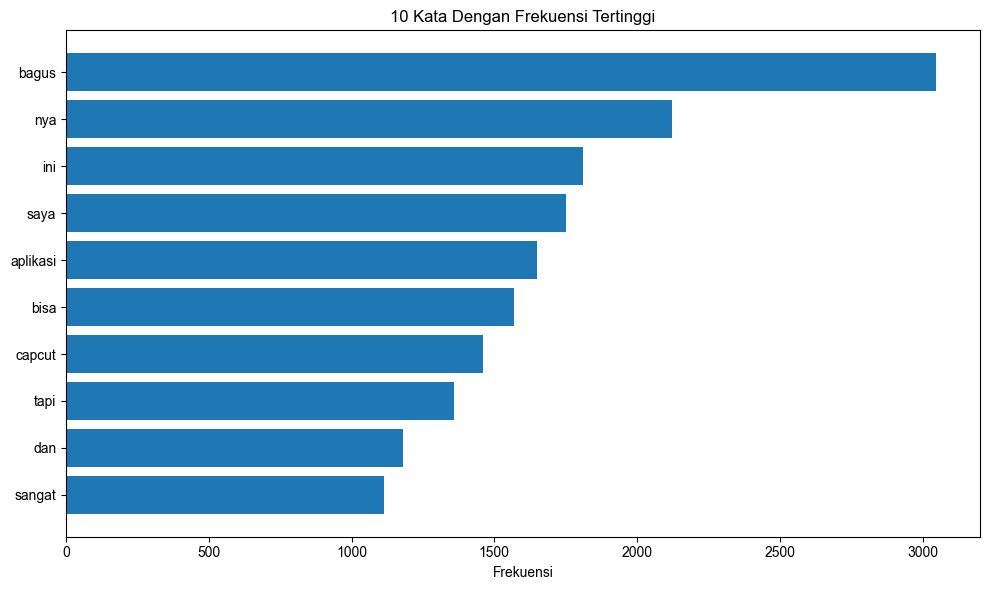

In [12]:

from collections import Counter
import re

all_text = " ".join(df['content'].dropna()).lower()
words = re.findall(r'\b[a-zA-Z]{3,}\b', all_text)

word_counts = Counter(words).most_common(10)

labels, values = zip(*word_counts)

plt.figure(figsize=(10,6))
plt.barh(labels, values)
plt.title("10 Kata Dengan Frekuensi Tertinggi")
plt.xlabel("Frekuensi")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [2]:
!pip install wordcloud


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


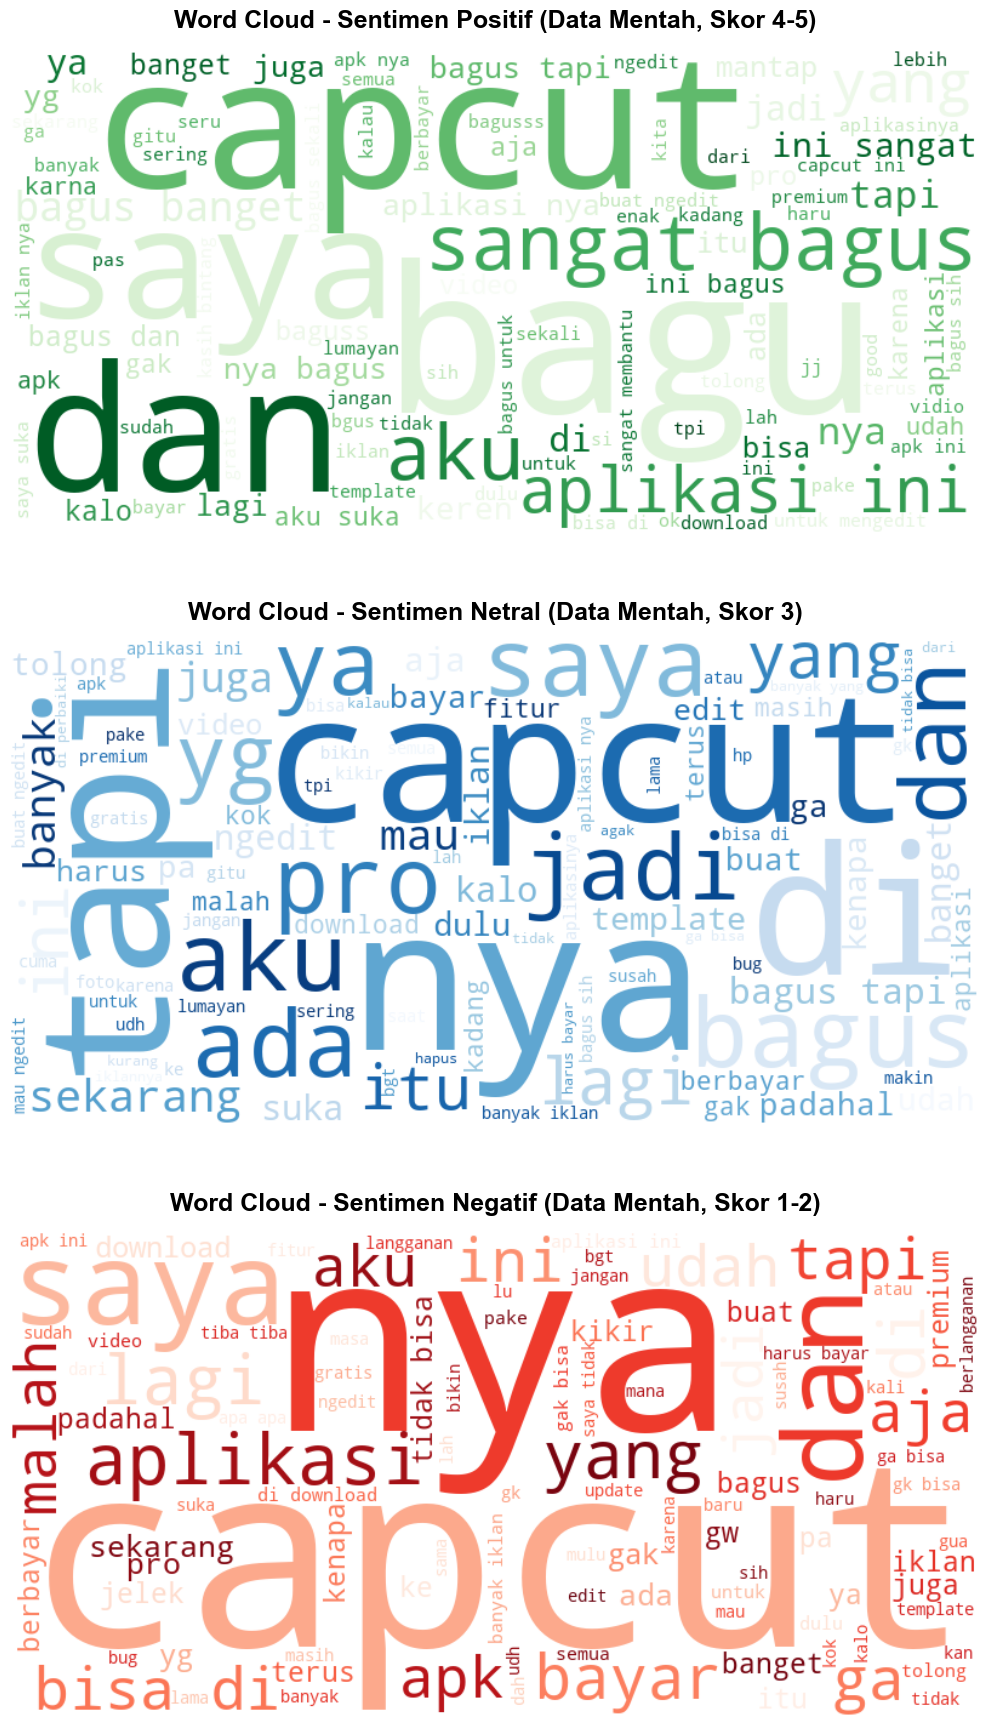

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Kategorisasi sentimen berdasarkan skor
def categorize_sentiment(score):
    if score <= 2:
        return 'Negatif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Positif'

df['sentiment_category'] = df['score'].apply(categorize_sentiment)

# 2. Menggabungkan teks mentah (kolom 'content') untuk masing-masing kategori
# Menggunakan dropna() untuk menghindari error jika ada ulasan yang kosong, lalu diubah ke string
text_positif = " ".join(df[df['sentiment_category'] == 'Positif']['content'].dropna().astype(str))
text_netral = " ".join(df[df['sentiment_category'] == 'Netral']['content'].dropna().astype(str))
text_negatif = " ".join(df[df['sentiment_category'] == 'Negatif']['content'].dropna().astype(str))

# 3. Inisialisasi konfigurasi Word Cloud
# Secara default, pustaka WordCloud sudah membuang kata hubung (stopwords) dasar bahasa Inggris
wc_positif = WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=100).generate(text_positif)
wc_netral = WordCloud(width=800, height=400, background_color='white', colormap='Blues', max_words=100).generate(text_netral)
wc_negatif = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(text_negatif)

# 4. Visualisasi dalam bentuk subplot (3 baris, 1 kolom)
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

axes[0].imshow(wc_positif, interpolation='bilinear')
axes[0].set_title('Word Cloud - Sentimen Positif (Data Mentah, Skor 4-5)', fontsize=18, fontweight='bold', pad=15)
axes[0].axis('off')

axes[1].imshow(wc_netral, interpolation='bilinear')
axes[1].set_title('Word Cloud - Sentimen Netral (Data Mentah, Skor 3)', fontsize=18, fontweight='bold', pad=15)
axes[1].axis('off')

axes[2].imshow(wc_negatif, interpolation='bilinear')
axes[2].set_title('Word Cloud - Sentimen Negatif (Data Mentah, Skor 1-2)', fontsize=18, fontweight='bold', pad=15)
axes[2].axis('off')

plt.tight_layout()
plt.show()

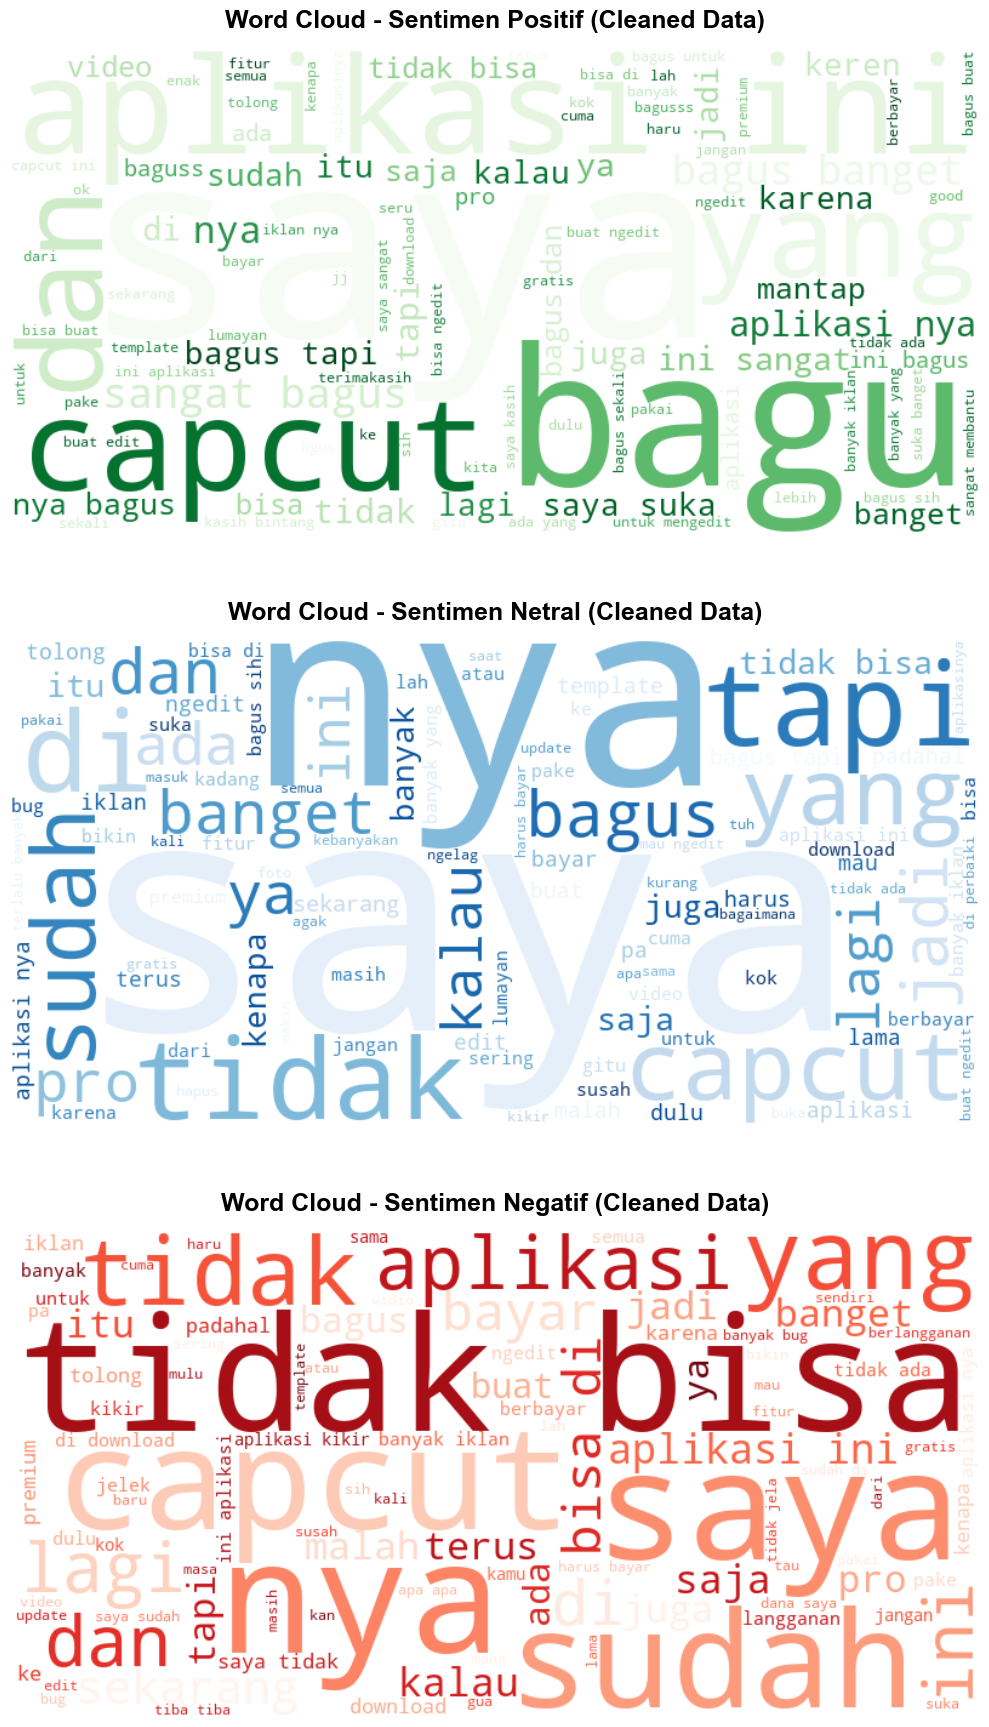

In [20]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Memuat dataset yang sudah dibersihkan
df_cleaned = pd.read_csv('../csv/capcut_reviews_cleaned.csv')

# 2. Kategorisasi sentimen berdasarkan skor
def categorize_sentiment(score):
    if score <= 2:
        return 'Negatif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Positif'

df_cleaned['sentiment_category'] = df_cleaned['score'].apply(categorize_sentiment)

# 3. Menggabungkan teks bersih untuk masing-masing kategori
# Menggunakan kolom 'clean_text'
col_name = 'clean_text'

text_positif = " ".join(df_cleaned[df_cleaned['sentiment_category'] == 'Positif'][col_name].dropna().astype(str))
text_netral = " ".join(df_cleaned[df_cleaned['sentiment_category'] == 'Netral'][col_name].dropna().astype(str))
text_negatif = " ".join(df_cleaned[df_cleaned['sentiment_category'] == 'Negatif'][col_name].dropna().astype(str))

# Membersihkan karakter sisa dari format CSV
for char in ["'", '"', "[", "]", ","]:
    text_positif = text_positif.replace(char, "")
    text_netral = text_netral.replace(char, "")
    text_negatif = text_negatif.replace(char, "")

# 4. Inisialisasi Word Cloud
wc_positif = WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=100).generate(text_positif)
wc_netral = WordCloud(width=800, height=400, background_color='white', colormap='Blues', max_words=100).generate(text_netral)
wc_negatif = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(text_negatif)

# 5. Visualisasi Subplot
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

axes[0].imshow(wc_positif, interpolation='bilinear')
axes[0].set_title('Word Cloud - Sentimen Positif (Cleaned Data)', fontsize=18, fontweight='bold', pad=15)
axes[0].axis('off')

axes[1].imshow(wc_netral, interpolation='bilinear')
axes[1].set_title('Word Cloud - Sentimen Netral (Cleaned Data)', fontsize=18, fontweight='bold', pad=15)
axes[1].axis('off')

axes[2].imshow(wc_negatif, interpolation='bilinear')
axes[2].set_title('Word Cloud - Sentimen Negatif (Cleaned Data)', fontsize=18, fontweight='bold', pad=15)
axes[2].axis('off')

plt.tight_layout()
plt.show()
     